<a href="https://colab.research.google.com/github/Auta01/Tensorflow-cases/blob/main/Creating%20Multi-Class%20cnn%20model%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Multi- class image classification

1. Become one with the data

2. Preprocess the data

3.Create a model
4.fit the model
5.Evaluate the model
6.Adjust different hyperparameter
7.Repeat untill satisfied

In [2]:
# Become one with the data
import zipfile

!wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_all_data.zip
zip_ref =zipfile.ZipFile('10_food_classes_all_data.zip', 'r')
zip_ref.extractall()
zip_ref.close()

--2026-01-30 23:20:07--  https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_all_data.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.137.207, 142.250.141.207, 142.250.101.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.137.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 519183241 (495M) [application/zip]
Saving to: ‘10_food_classes_all_data.zip’

10_food_classes_all 100%[===================>] 495.13M  38.1MB/s    in 7.5s    

2026-01-30 23:20:15 (65.9 MB/s) - ‘10_food_classes_all_data.zip’ saved [519183241/519183241]



In [3]:
import os

#walk through 10 classes of food image data
for dirpath, dirnames, filenames, in os.walk('10_food_classes_all_data'):
  print(f'There are {len(dirnames)} directories and {len(filenames)} images in {dirpath}''.')

There are 2 directories and 0 images in 10_food_classes_all_data.
There are 10 directories and 0 images in 10_food_classes_all_data/test.
There are 0 directories and 250 images in 10_food_classes_all_data/test/ramen.
There are 0 directories and 250 images in 10_food_classes_all_data/test/chicken_curry.
There are 0 directories and 250 images in 10_food_classes_all_data/test/grilled_salmon.
There are 0 directories and 250 images in 10_food_classes_all_data/test/sushi.
There are 0 directories and 250 images in 10_food_classes_all_data/test/pizza.
There are 0 directories and 250 images in 10_food_classes_all_data/test/fried_rice.
There are 0 directories and 250 images in 10_food_classes_all_data/test/hamburger.
There are 0 directories and 250 images in 10_food_classes_all_data/test/steak.
There are 0 directories and 250 images in 10_food_classes_all_data/test/chicken_wings.
There are 0 directories and 250 images in 10_food_classes_all_data/test/ice_cream.
There are 10 directories and 0 ima

In [4]:
train_dir = '10_food_classes_all_data/train/'
test_dir = '10_food_classes_all_data/test/'

In [5]:
#lets get the class names
import pathlib
import numpy as np
data_dir = pathlib.Path(train_dir)
class_names = np.array(sorted([item.name for item in data_dir.glob('*')]))
print(class_names)

['chicken_curry' 'chicken_wings' 'fried_rice' 'grilled_salmon' 'hamburger'
 'ice_cream' 'pizza' 'ramen' 'steak' 'sushi']


Image shape: (341, 512, 3)


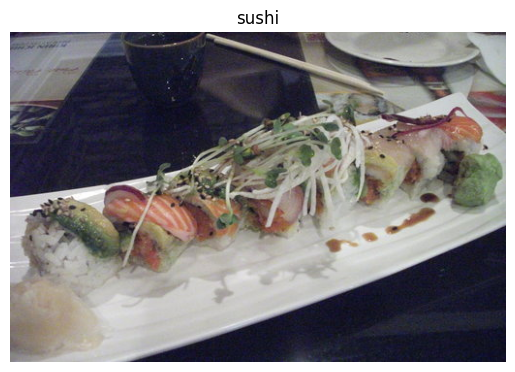

In [6]:
#Visualize, visualize, Visualize
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

def view_random_image(target_dir, target_class):
  # Setup target directory (we'll pretend to only work with the training data))
  target_folder = target_dir + target_class

  # Get a random image path
  random_image = random.sample(os.listdir(target_folder), 1)

  # Read in the image and plot it using matplotlib
  img = mpimg.imread(target_folder + '/' + random_image[0])
  plt.imshow(img)
  plt.title(target_class)
  plt.axis('off')
  print(f"Image shape: {img.shape}") # show the shape of the image
  return img

img = view_random_image(target_dir =train_dir,
                        target_class=random.choice(class_names))

In [7]:
# preprocess the data(prepare it for the model)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#Rescale

train_datagen = ImageDataGenerator(rescale=1/255.)

test_datagen = ImageDataGenerator(rescale=1/255.)

#load data in from directories and turn it into batch

train_data =train_datagen.flow_from_directory(train_dir,
                                                target_size=(224,224),
                                                batch_size=32,
                                                class_mode='categorical')

test_data =test_datagen.flow_from_directory(test_dir,
                                              target_size=(224, 224),
                                              batch_size=32,
                                              class_mode='categorical')

Found 7500 images belonging to 10 classes.
Found 2500 images belonging to 10 classes.


In [8]:
#create the cnn  model
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense
model = Sequential([
    Conv2D(10, 3, activation='relu', input_shape=(224, 224,3)),
    Conv2D(10, 3, activation='relu'),
    MaxPool2D(),
    Conv2D(10,3, activation='relu'),
    Conv2D(10,3, activation='relu'),
    MaxPool2D(),
    Flatten(),
    Dense(10, activation='softmax')
])

#Compile the model
model.compile(loss='categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(),
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
#fit the model
history = model.fit(train_data,
                    epochs=5,
                    steps_per_epoch=len(train_data),
                    validation_data=test_data,
                    validation_steps=len(test_data))

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 529s 2s/step - accuracy: 0.1471 - loss: 2.2503 - val_accuracy: 0.3340 - val_loss: 1.8949
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 515s 2s/step - accuracy: 0.3622 - loss: 1.8519 - val_accuracy: 0.3696 - val_loss: 1.8222
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 508s 2s/step - accuracy: 0.5029 - loss: 1.5083 - val_accuracy: 0.3604 - val_loss: 1.8730
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 562s 2s/step - accuracy: 0.7099 - loss: 0.9251 - val_accuracy: 0.3112 - val_loss: 2.2680
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 553s 2s/step - accuracy: 0.9019 - loss: 0.3594 - val_accuracy: 0.3164 - val_loss: 3.1089


In [10]:
#Evaluating the model
model.evaluate(train_data)

235/235 ━━━━━━━━━━━━━━━━━━━━ 156s 661ms/step - accuracy: 0.9796 - loss: 0.1293


[0.12801630795001984, 0.9783999919891357]

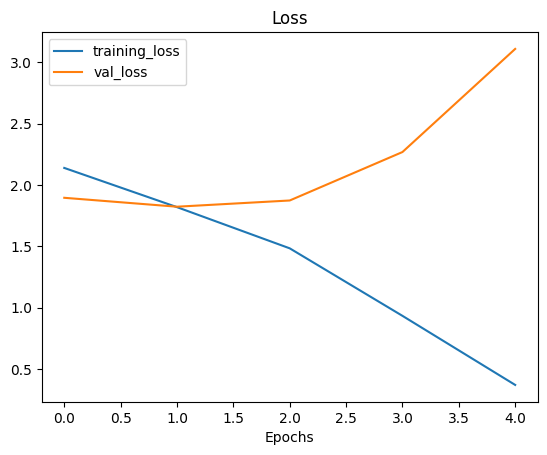

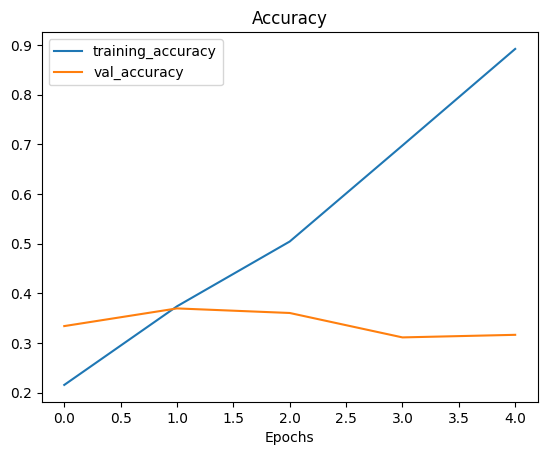

In [11]:
#check out model loss curves
import matplotlib.pyplot as plt

def plot_loss_curves(history):
  """
  Returns separate loss curves and accuracy curves.
  """
  loss = history.history['loss']
  val_loss = history.history['val_loss']

  accuracy = history.history['accuracy']
  val_accuracy = history.history['val_accuracy']

  epochs = range(len(history.history['loss']))

  # Plot loss
  plt.plot(epochs, loss, label='training_loss')
  plt.plot(epochs, val_loss, label='val_loss')
  plt.title('Loss')
  plt.xlabel('Epochs')
  plt.legend()

  # Plot accuracy
  plt.figure()
  plt.plot(epochs, accuracy, label='training_accuracy')
  plt.plot(epochs, val_accuracy, label='val_accuracy')
  plt.title('Accuracy')
  plt.xlabel('Epochs')
  plt.legend()

plot_loss_curves(history)

What do these loss curves tells us
it seems our model is ovefitting

In [12]:
#Adjust the model hyperparameter/Reduce overfitting

#lets simpilfy the model

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 110, 110, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 108, 108, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 106, 106, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 53, 53, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28090)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │       280,910 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 851,762 (3.25 MB)

 Trainable params: 283,920 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 567,842 (2.17 MB)

In [13]:
#Let simpilfy the model

model_2 =Sequential([
    Conv2D(10,3, activation ='relu', input_shape=(224, 224,3)),
    MaxPool2D(),
    Conv2D(10,3, activation='relu'),
    MaxPool2D(),
    Flatten(),
    Dense(10, activation='softmax')
])

model_2.compile(loss='categorical_crossentropy',
                optimizer=tf.keras.optimizers.Adam(),
                metrics=['accuracy'])

history_2 =model_2.fit(train_data,
                       epochs=5,
                       steps_per_epoch=len(train_data),
                       validation_data=test_data,
                       validation_steps=len(test_data))

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 240s 1s/step - accuracy: 0.1523 - loss: 2.6094 - val_accuracy: 0.2800 - val_loss: 2.0185
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 274s 1s/step - accuracy: 0.3578 - loss: 1.8662 - val_accuracy: 0.2988 - val_loss: 1.9841
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 245s 1s/step - accuracy: 0.5097 - loss: 1.4932 - val_accuracy: 0.3196 - val_loss: 2.0038
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 246s 1s/step - accuracy: 0.6868 - loss: 1.0277 - val_accuracy: 0.2896 - val_loss: 2.3223
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 259s 1s/step - accuracy: 0.8490 - loss: 0.5702 - val_accuracy: 0.2928 - val_loss: 2.6080


In [14]:
model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 111, 111, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 109, 109, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 54, 54, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 29160)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │       291,610 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 878,402 (3.35 MB)

 Trainable params: 292,800 (1.12 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 585,602 (2.23 MB)

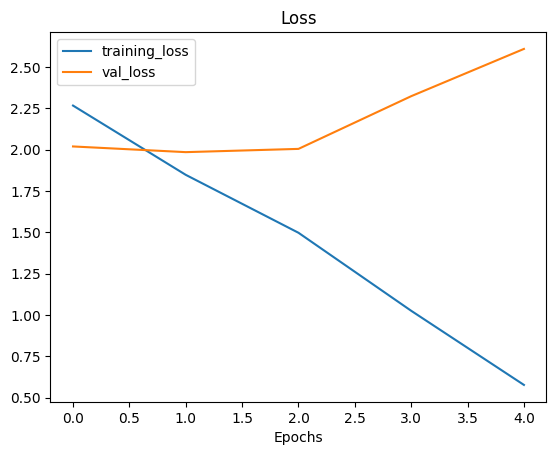

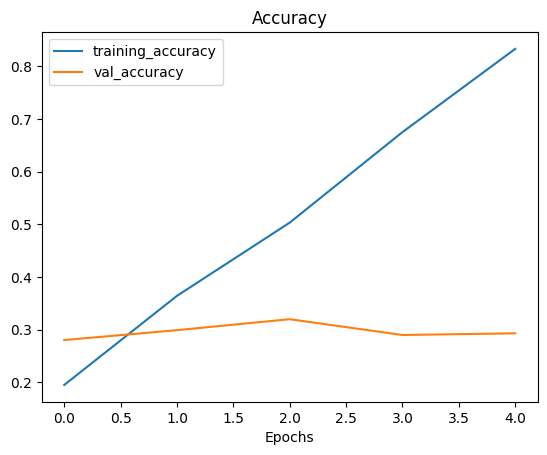

In [15]:
plot_loss_curves(history_2)

Simplifying the model it did'nt work lets try data augmentation

In [16]:
#Trying to reduce overfitting wwith data augmentation
#Create an augmented data

train_datagen_augmented = ImageDataGenerator(rescale=1/255.,
                                             rotation_range=0.2,
                                             width_shift_range=0.2,
                                             height_shift_range=0.2,
                                             zoom_range=0.2,
                                             horizontal_flip=True)
train_data_augmented = train_datagen_augmented.flow_from_directory(train_dir,
                                                                   target_size=(224,224),
                                                                   batch_size=32,
                                                                   class_mode='categorical')


Found 7500 images belonging to 10 classes.


In [17]:
#lets create another modle to trainit on the augmented
model_3 =tf.keras.models.clone_model(model_2)

#compile the clone model
model_3.compile(loss='categorical_crossentropy',
                optimizer=tf.keras.optimizers.Adam(),
                metrics=['accuracy'])


In [18]:
#fit the model
history_3 = model_3.fit(train_data_augmented,
                        epochs=5,
                        steps_per_epoch =len(train_data_augmented),
                        validation_data =test_data,
                        validation_steps=len(test_data))

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 319s 1s/step - accuracy: 0.1617 - loss: 2.3927 - val_accuracy: 0.2940 - val_loss: 2.0132
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 316s 1s/step - accuracy: 0.2699 - loss: 2.0749 - val_accuracy: 0.2716 - val_loss: 2.0985
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 320s 1s/step - accuracy: 0.2869 - loss: 2.0312 - val_accuracy: 0.3248 - val_loss: 1.9214
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 329s 1s/step - accuracy: 0.2999 - loss: 2.0136 - val_accuracy: 0.3556 - val_loss: 1.8673
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 380s 1s/step - accuracy: 0.3201 - loss: 1.9661 - val_accuracy: 0.3696 - val_loss: 1.8529


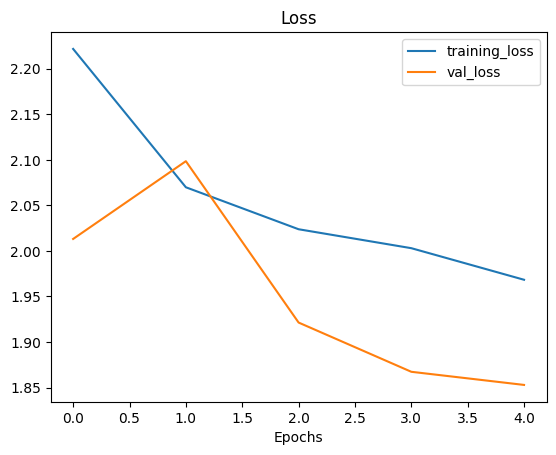

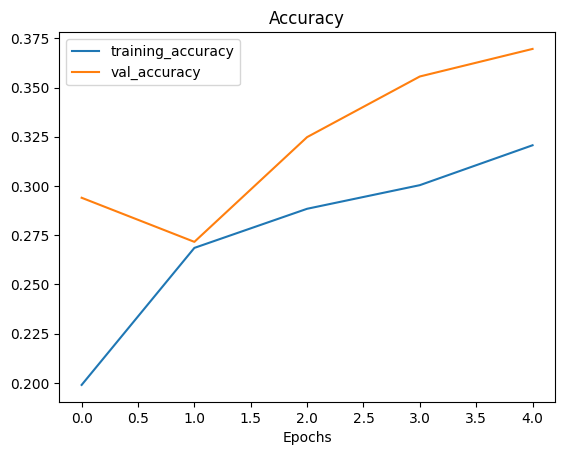

In [19]:
plot_loss_curves(history_3)